> # Circuit Library

Reference: https://quantum.cloud.ibm.com/docs/en/guides/circuit-library

In [1]:
from platform import python_version
import qiskit
print("Python version ", python_version())
print(f"Qiskit version: {qiskit.__version__}")

Python version  3.13.5
Qiskit version: 2.5.0


> # Standard gates

Reference: 

https://quantum.cloud.ibm.com/docs/en/api/qiskit/circuit_library#standard-gates

https://quantum.cloud.ibm.com/docs/guides/composer#quantum-gates

> # Single qubit gates

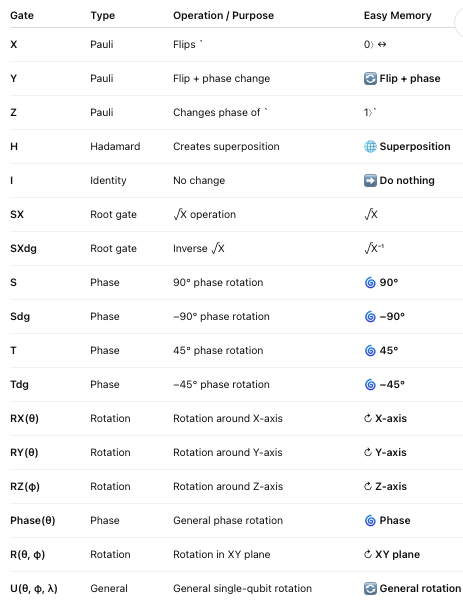

In [1]:
from IPython import display
display.Image("./STD_gates/pic2.png")

> # Two qubit gates

![](./STD_gates/pic3.PNG)


> # Three qubit gates

![](./STD_gates/pic4.PNG)

![](./STD_gates/pic11.PNG)

> # Phase 

![](./STD_gates/pic6.PNG)

![](./STD_gates/pic7.PNG)

![](./STD_gates/pic8.PNG)

![](./STD_gates/pic5.PNG)

> # Barrier:
https://quantum.cloud.ibm.com/docs/en/api/qiskit/circuit#qiskit.circuit.Barrier

<h3>

A directive for circuit compilation to separate pieces of a circuit so that any optimizations or re-writes are constrained to only act between barriers.

Appear in visualizations as a visual marker.

</h3>

> # non-reversible changes in the quantum state of the circuit

- ## Measure
- ## Reset


> # Boolean Logic

<h3>

1. **logical AND operation**
- AndGate	 

2. **logical OR operation**
- OrGate   

3. **bitwise xor-ing**
- BitwiseXorGate :n-qubit gate

4. **Inner Product of two n-qubit vectors**
- InnerProductGate

</h3>

> # 2 control 1 target: 3 - qubit

1. ccx

2. AndGate

3. MCXGate

4. MCMTGate

5. Xgate, control()method

> ### Called as "Toffoli Gate"

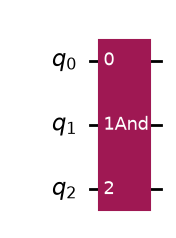

In [2]:
from qiskit.circuit.library import AndGate

from qiskit.circuit import QuantumCircuit

qc=QuantumCircuit(3)

qc.append(AndGate(2),[0,1,2])

qc.draw("mpl")

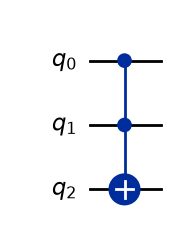

In [3]:
qc.decompose().draw("mpl")

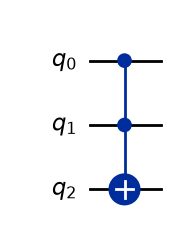

In [4]:
from qiskit.circuit.library import MCXGate
mcx = MCXGate(2)

circuit = QuantumCircuit(3)
circuit.append(mcx, [0, 1,2])
circuit.draw("mpl")

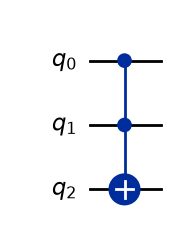

In [5]:
from qiskit.circuit.library import CCXGate
circuit = QuantumCircuit(3)

circuit.ccx(0,1,2)

circuit.draw("mpl")

https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.MCMTGate

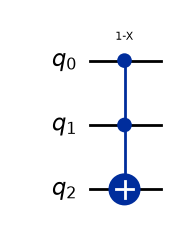

In [6]:


from qiskit.circuit.library import MCMTGate, XGate

mcmt = MCMTGate(
    XGate(),
    num_ctrl_qubits=2,
    num_target_qubits=1
)

circuit = QuantumCircuit(3)

circuit.append(mcmt, [0, 1, 2])

circuit.draw("mpl")

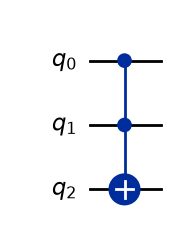

In [7]:
from qiskit.circuit.library import XGate

qc = QuantumCircuit(3)

ctrl_x = XGate().control(2)  

qc.append(ctrl_x, [0,1,2])     

qc.draw("mpl")

> # Fredkin gate

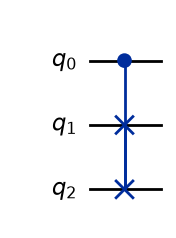

In [8]:
from qiskit.circuit.library import CSwapGate


circuit = QuantumCircuit(3)

circuit.cswap(0,1,2) # control: q0 , swap: q1,q2

circuit.draw("mpl")

> # simplified Toffoli 

-  not equivalent to the Toffoli

- Implements the Toffoli gate up to relative phases


REFERENCE: 

https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.RCCXGate

https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.RC3XGate

> # RCCXGate :  Margolus gate,simplified Toffoli gate

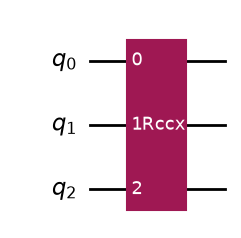

In [9]:
from qiskit.circuit.library import RCCXGate


circuit = QuantumCircuit(3)
circuit.rccx(0,1,2)
circuit.draw("mpl")

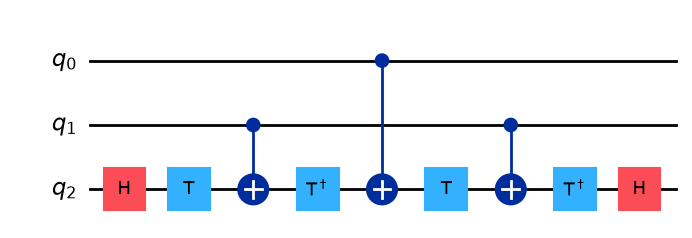

In [10]:
circuit.decompose().draw("mpl")

> # RC3XGate: simplified 3-controlled Toffoli gate.

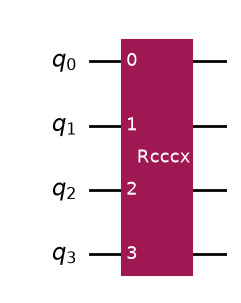

In [11]:
from qiskit.circuit.library import RC3XGate


circuit = QuantumCircuit(4)

circuit.append(RC3XGate(), [0, 1, 2, 3])
circuit.draw("mpl")

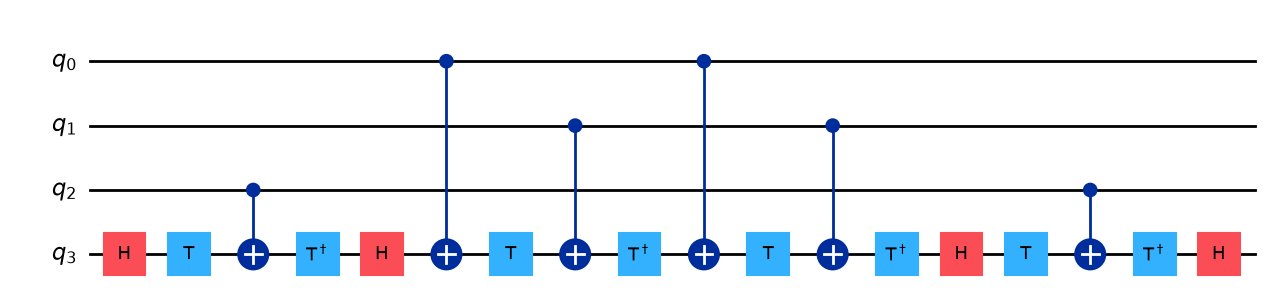

In [12]:
circuit.decompose().draw("mpl")

In [13]:
qc= circuit.decompose()

count_2q = sum(
    len(instruction.qubits) == 2
    for instruction in qc.data
)
print("Number of 2-qubit gates:", count_2q)

Number of 2-qubit gates: 6


> # Mølmer–Sørensen gate ------> MSGate

> # to_matrix(): Returns the unitary matrix representation

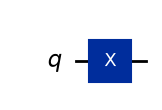

In [14]:
circuit = QuantumCircuit(1)

circuit.x(0)
circuit.draw("mpl")

In [15]:
from qiskit.quantum_info import Operator
# Matrix representation

print(Operator(circuit).data)

[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]


In [16]:
from qiskit.visualization import array_to_latex

array_to_latex(Operator(circuit))

<IPython.core.display.Latex object>

> # Complex amplitude intialization

https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.Initialize

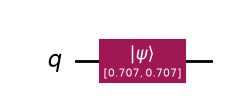

In [17]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import Initialize
from qiskit.quantum_info import Statevector

import numpy as np

# Create a 1-qubit circuit
circuit = QuantumCircuit(1)

# |+> state
state = [1/np.sqrt(2), 1/np.sqrt(2)]

# Create Initialize instruction
init = Initialize(state)

# Add it to the circuit
circuit.append(init, [0])

# Draw circuit
circuit.draw("mpl")

In [18]:
final_state = Statevector.from_instruction(circuit)

array_to_latex(final_state)

<IPython.core.display.Latex object>

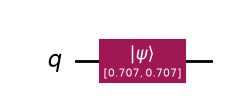

In [19]:
from qiskit import QuantumCircuit
import numpy as np

circuit = QuantumCircuit(1)

state = [1/np.sqrt(2), 1/np.sqrt(2)]

circuit.initialize(state, 0)

circuit.draw("mpl")

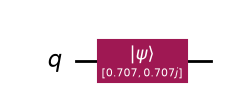

In [20]:


# Complex amplitudes
alpha = 1 / np.sqrt(2)
beta = 1j / np.sqrt(2)

state = [alpha, beta]

# Create circuit
circuit = QuantumCircuit(1)

# Initialize qubit
init = Initialize(state)
circuit.append(init, [0])

# Draw
circuit.draw("mpl")



In [21]:
# Check statevector

final_state = Statevector.from_instruction(circuit)

array_to_latex(final_state)

<IPython.core.display.Latex object>

In [22]:
final_state.is_valid()

True

<h3>

Gate have following methods : 

 - to_matrix(), 
 - power(), and 
 - control(),
 
  generally only apply to unitary operations
  </h3>

> # √X gate :single-qubit Sqrt(X) gate ,√X

<h3>

1. SXGate

2. Xgate, to_power() method

</h3>

In [23]:
from qiskit.circuit.library import XGate
gate = XGate()

print(gate.power(1/2).to_matrix())  # √X gate -- see also the SXGate

array_to_latex(gate.power(1/2).to_matrix())

[[0.5+0.5j 0.5-0.5j]
 [0.5-0.5j 0.5+0.5j]]


<IPython.core.display.Latex object>

In [24]:
from qiskit.circuit.library import SXGate
# Create circuit
circuit = QuantumCircuit(1)

circuit.sx(0)
array_to_latex(Operator(circuit))

<IPython.core.display.Latex object>

> # Symmetric gate: CCZ

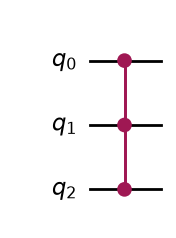

In [25]:
circuit = QuantumCircuit(3)

circuit.ccz(0,1,2)
circuit.draw("mpl")

> # iswap: Clifford and symmetric gate

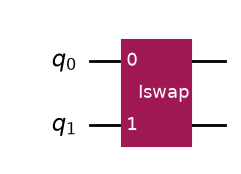

In [26]:
circuit = QuantumCircuit(2)

circuit.iswap(0,1)
circuit.draw("mpl")

In [27]:
array_to_latex(Operator(circuit))

<IPython.core.display.Latex object>

<h3>

- 2-qubit XX+YY interaction. 

-  Swap two qubit states and phase the ∣01⟩ and ∣10⟩ amplitudes by i

</h3>

<img src="./STD_gates/pic12.PNG" width="200" height="200">

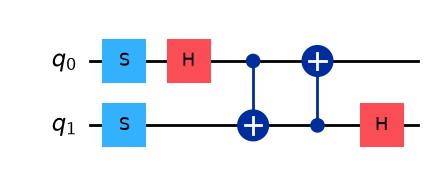

In [28]:
circuit.decompose().draw("mpl")

> # Gates depending on number of controls
<h3>

1 control → CXGate()

2 controls → CCXGate()

3 controls → C3XGate()

4 controls → C4XGate()
</h3>

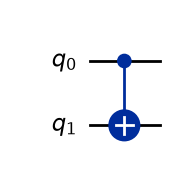

In [29]:
circuit = QuantumCircuit(2)
circuit.cx(0,1)
circuit.draw("mpl")

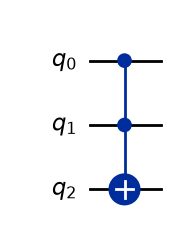

In [30]:
circuit = QuantumCircuit(3)
circuit.ccx(0,1,2)
circuit.draw("mpl")

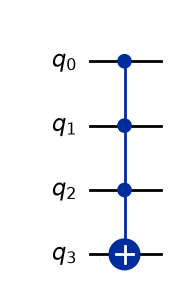

In [31]:
from qiskit.circuit.library import C3XGate

circuit = QuantumCircuit(4)

#X gate controlled on 3 qubits.
circuit.append(
    C3XGate(),
    [0, 1, 2, 3],
)
circuit.draw("mpl")

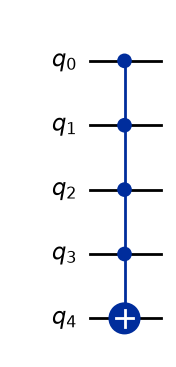

In [32]:
from qiskit.circuit.library import C4XGate

circuit = QuantumCircuit(5)

#X gate controlled on 4 qubits.
circuit.append(
    C4XGate(),
    [0, 1, 2, 3,4],
)
circuit.draw("mpl")

> # DCX: 2-qubit Clifford gate 

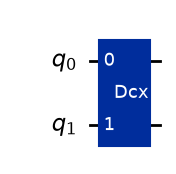

In [33]:
from qiskit.circuit.library import DCXGate

circuit = QuantumCircuit(2)

circuit.append(
   DCXGate(),
    [0, 1],
)
circuit.draw("mpl")

### Consists of two back-to-back CX gates with alternate controls

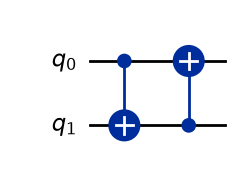

In [34]:
circuit.decompose().draw("mpl")